In [4]:
## Workflow stages
    # The competition solution workflow goes through seven stages described in the Data Science Solutions book.

    1. Question or problem definition.
    2. Acquire training and testing data.
    3. Wrangle, prepare, cleanse the data.
    4. Analyze, identify patterns, and explore the data.
    5. Model, predict and solve the problem.
    6. Visualize, report, and present the problem solving steps and final solution.
    7. Supply or submit the results.

IndentationError: unexpected indent (3609348650.py, line 4)

In [5]:
# data analysis and wrangling 
import pandas as pd
import numpy as np
import random as rnd

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns 

## File Acquiring : 
    The Python Pandas packages helps us work with our datasets. We start by acquiring the training and testing datasets into Pandas DataFrames. We also combine these datasets to run certain operations on both datasets together.

In [6]:
train_df = pd.read_csv('titanic_train_data.csv')
test_df = pd.read_csv('titanic_test_data.csv') 

In [10]:
print(train_df.columns.values) 

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


### Which features are categorical?
    These values classify the samples into sets of similar samples. Within categorical features are the values nominal, ordinal, ratio, or interval based? Among other things this helps us select the appropriate plots for visualization.
    
    Categorical: Survived, Sex, and Embarked. Ordinal: Pclass.
                
### @hich features are numerical?
    Which features are numerical? These values change from sample to sample. Within numerical features are the values discrete, continuous, or timeseries based? Among other things this helps us select the appropriate plots for visualization.
    
    Continous: Age, Fare. Discrete: SibSp, Parch.

## Preview the data : 

In [4]:
train_df.head ()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train_df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### these commands helps to chech basic data about the dataset like : 
    Which features may contain errors or typos?
    Which features contain blank, null or empty values?
    What are the data types for various features?
    Which features are mixed data types?

In [6]:
train_df.info ()
print ( '-'* 40 ) 
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passenger

## What is the distribution of numerical feature values across the samples?
    This helps us determine, among other early insights, how representative is the training dataset of the actual problem domain.

    - Total samples are 891 or 40% of the actual number of passengers on board the Titanic (2,224).
    - Survived is a categorical feature with 0 or 1 values.
    - Age feature is define in float value whereas it should be in integer value.
    - Most passengers (> 75%) did not travel with parents or children.
    - Nearly 30% of the passengers had siblings and/or spouse aboard.
    - Fares varied significantly with few passengers (<1%) paying as high as $512.
    - Few elderly passengers (<1%) within age range 65-80.
    - Cabin feature has most null values 

In [7]:
train_df.describe()
# Review survived rate using `percentiles=[.61, .62]` knowing our problem description mentions 38% survival rate.
# Review Parch distribution using `percentiles=[.75, .8]`
# SibSp distribution `[.68, .69]`
# Age and Fare `[.1, .2, .3, .4, .5, .6, .7, .8, .9, .99]`

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## What is the distribution of categorical features?

    - Names are unique across the dataset (count=unique=891)
    - Sex variable as two possible values with 65% male (top=male, freq=577/count=891).
    - Cabin values have several dupicates across samples. Alternatively several passengers shared a cabin.
    - Embarked takes three possible values. S port used by most passengers (top=S)
    - Ticket feature has high ratio (22%) of duplicate values (unique=681).

In [8]:
train_df.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


# Data Wrangling : 

### Assumtions based on data analysis
    We arrive at following assumptions based on data analysis done so far. We may validate these assumptions further before taking appropriate actions.

### Correlating.
    We want to know how well does each feature correlate with Survival. We want to do this early in our project and match these quick correlations with modelled correlations later in the project.

## Completing.
    - We may want to complete Age feature as it is definitely correlated to survival.
    - We may want to complete the Embarked feature as it may also correlate with survival or another important feature.
    
### Correcting.
    - Ticket feature may be dropped from our analysis as it contains high ratio of duplicates (22%) and there may not be a correlation       between Ticket and survival.
    - Cabin feature may be dropped as it is highly incomplete or contains many null values both in training and test dataset. 
    - PassengerId may be dropped from training dataset as it does not contribute to survival.
    - Name feature is relatively non-standard, may not contribute directly to survival, so maybe dropped.

### Creating.
    - We may want to create a new feature called Family based on Parch and SibSp to get total count of family members on board.
    - We may want to engineer the Name feature to extract Title as a new feature.
    - We may want to create new feature for Age bands. This turns a continous numerical feature into an ordinal categorical feature.
    - We may also want to create a Fare range feature if it helps our analysis.

### Classifying.
    We may also add to our assumptions based on the problem description noted earlier.
    
    - Women (Sex=female) were more likely to have survived.
    - Children (Age<?) were more likely to have survived.
    - The upper-class passengers (Pclass=1) were more likely to have survived.

In [9]:
train_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [10]:
train_df[["Sex", "Survived"]].groupby(['Sex'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [11]:
train_df[["SibSp", "Survived"]].groupby(['SibSp'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,SibSp,Survived
1,1,0.535885
2,2,0.464286
0,0,0.345395
3,3,0.250000
4,4,0.166667
5,5,0.000000
6,8,0.000000


In [12]:
train_df[["Parch", "Survived"]].groupby(['Parch'], as_index=False).mean().sort_values(by='Survived', ascending=False)

,Parch,Survived
3,3,0.600000
1,1,0.550847
2,2,0.500000
0,0,0.343658
5,5,0.200000
4,4,0.000000
6,6,0.000000


## Analyze by visualizing data
    Now we can continue confirming some of our assumptions using visualizations for analyzing the data.

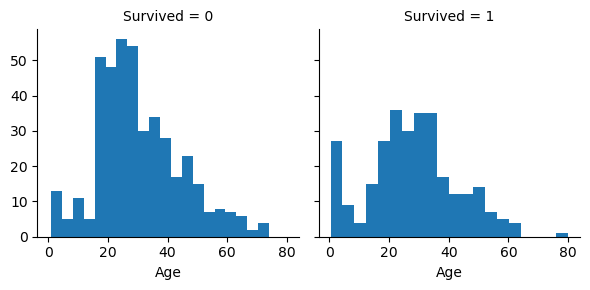

In [13]:
g = sns.FacetGrid(train_df, col='Survived')
g.map(plt.hist, 'Age', bins=20)

### Correlating numerical features¶
    Let us start by understanding correlations between numerical features and our solution goal (Survived).
    
    A histogram chart is useful for analyzing continous numerical variables like Age where banding or ranges will help identify useful patterns. The histogram can indicate distribution of samples using automatically defined bins or equally ranged bands. This helps us answer questions relating to specific bands (Did infants have better survival rate?)
    
    Note that x-axis in historgram visualizations represents the count of samples or passengers.

### Observations.
    - Infants (Age <=4) had high survival rate.
    - Oldest passengers (Age = 80) survived.
    - Large number of 15-25 year olds did not survive.
    - Most passengers are in 15-35 age range.
    
### Decisions.

    This simple analysis confirms our assumptions as decisions for subsequent workflow stages.
    
    - We should consider Age (our assumption classifying #2) in our model training.
    - Complete the Age feature for null values (completing #1).
    - We should band age groups (creating #3).

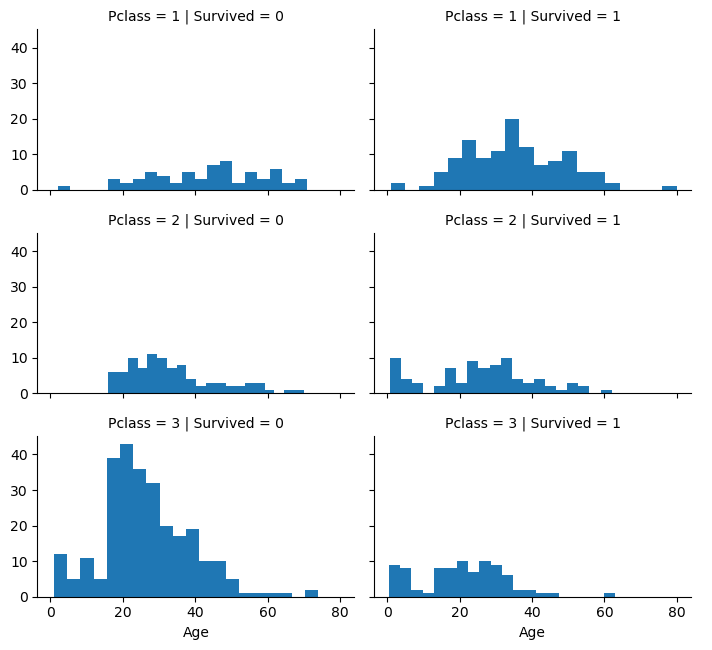

In [14]:
# grid = sns.FacetGrid ( train_df, hue = 'Survived', col = 'Pclass' ) 
grid = sns.FacetGrid ( train_df, col = 'Survived', row = 'Pclass', height = 2.2 , aspect = 1.6 ) 
grid.map( plt.hist , 'Age', alpha = 1, bins = 20 ) 
grid.add_legend()

### Correlating numerical and ordinal features
    We can combine multiple features for identifying correlations using a single plot. This can be done with numerical and categorical features which have numeric values.
    
### Observations.
    - Pclass=3 had most passengers, however most did not survive. Confirms our classifying assumption #2.
    - Infant passengers in Pclass=2 and Pclass=3 mostly survived. Further qualifies our classifying assumption #2.
    - Most passengers in Pclass=1 survived. Confirms our classifying assumption #3.
    - Pclass varies in terms of Age distribution of passengers.

### Decisions.
    - Consider Pclass for model training.

C:\Users\amans\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\amans\anaconda3\Lib\site-packages\seaborn\axisgrid.py:723: UserWarning: Using the pointplot function without specifying `hue_order` is likely to produce an incorrect plot.
  warnings.warn(warning)


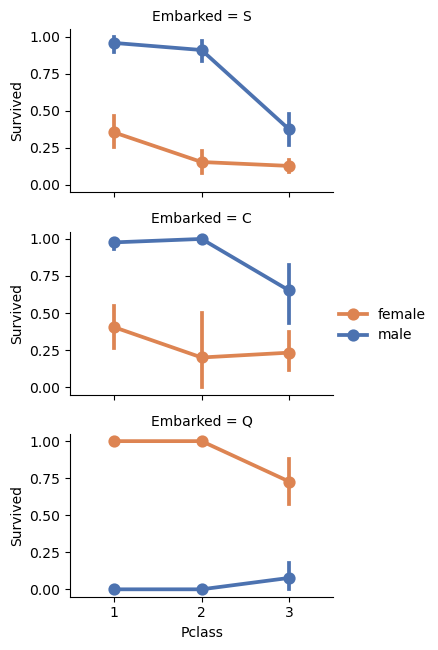

In [15]:
# grid = sns.FacetGrid(train_df, col='Embarked')
grid = sns.FacetGrid(train_df, row='Embarked', height =2.2, aspect=1.6)
grid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', palette='deep')
grid.add_legend()

### Correlating categorical features¶
    Now we can correlate categorical features with our solution goal.

### Observations.
    - Female passengers had much better survival rate than males. Confirms classifying (#1).
    - Exception in Embarked=C where males had higher survival rate. This could be a correlation between Pclass and Embarked and in turn Pclass and Survived, not necessarily direct correlation between Embarked and Survived.
    - Males had better survival rate in Pclass=3 when compared with Pclass=2 for C and Q ports. Completing (#2).
    - Ports of embarkation have varying survival rates for Pclass=3 and among male passengers. Correlating (#1).

### Decisions.
    - Add Sex feature to model training.
    - Complete and add Embarked feature to model training.

C:\Users\amans\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
C:\Users\amans\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\amans\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\amans\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\amans\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\amans\anaco

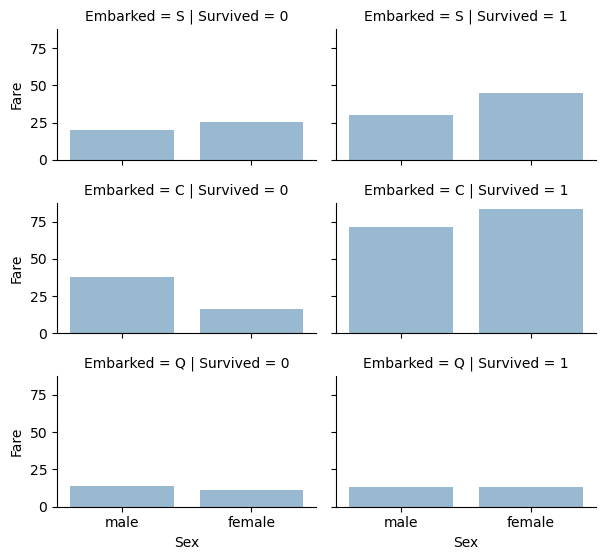

In [16]:
# grid = sns.FacetGrid(train_df, col='Embarked', hue='Survived', palette={0: 'k', 1: 'w'})
grid = sns.FacetGrid(train_df, row='Embarked', col='Survived', height =1.9, aspect=1.6)
grid.map(sns.barplot, 'Sex', 'Fare', alpha=.5, ci=None)
grid.add_legend()

### Correlating categorical and numerical features
    We may also want to correlate categorical features (with non-numeric values) and numeric features. We can consider correlating Embarked (Categorical non-numeric), Sex (Categorical non-numeric), Fare (Numeric continuous), with Survived (Categorical numeric).

### Observations.
    - Higher fare paying passengers had better survival. Confirms our assumption for creating (#4) fare ranges.
    - Port of embarkation correlates with survival rates. Confirms correlating (#1) and completing (#2).

### Decisions.
    - Consider banding Fare feature.

## Wrangle data¶
    We have collected several assumptions and decisions regarding our datasets and solution requirements. So far we did not have to change a single feature or value to arrive at these. Let us now execute our decisions and assumptions for correcting, creating, and completing goals.

In [17]:
print ( 'before : \n', 'train data shape :', train_df.shape, '\n test data shape :', test_df.shape,)  

train_df = train_df.drop(['Ticket', 'Cabin'], axis = 1 )
test_df.drop(['Ticket', 'Cabin'], axis = 1 , inplace = True ) 
combine = [train_df , test_df ]

print ( 'after : \n', 'train data shape :', train_df.shape, '\n test data shape :', test_df.shape,)  

before : 
 train data shape : (891, 12) 
 test data shape : (418, 11)
after : 
 train data shape : (891, 10) 
 test data shape : (418, 9)


### Correcting by dropping features
    This is a good starting goal to execute. By dropping features we are dealing with fewer data points. Speeds up our notebook and eases the analysis.
    
    Based on our assumptions and decisions we want to drop the Cabin (correcting #2) and Ticket (correcting #1) features.
    
    Note that where applicable we perform operations on both training and testing datasets together to stay consistent.

In [18]:
for dataset in combine : 
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.' , expand = False) 

pd.crosstab( train_df['Title'], train_df['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


### Creating new feature extracting from existing
    We want to analyze if Name feature can be engineered to extract titles and test correlation between titles and survival, before dropping Name and PassengerId features.
    In the following code we extract Title feature using regular expressions. The RegEx pattern (\w+\.) matches the first word which ends with a dot character within Name feature. The expand=False flag returns a DataFrame.

### Observations.
    When we plot Title, Age, and Survived, we note the following observations.
    
    - Most titles band Age groups accurately. For example: Master title has Age mean of 5 years. 
    - Survival among Title Age bands varies slightly.
    - Certain titles mostly survived (Mme, Lady, Sir) or did not (Don, Rev, Jonkheer).

### Decision.
    - We decide to retain the new Title feature for model training.

In [19]:
train_df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Don', 'Rev', 'Dr', 'Mme', 'Ms',
       'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess',
       'Jonkheer'], dtype=object)

In [20]:
for dataset in combine : 
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace(['Don', 'Rev', 'Dr', 'Major', 'Lady', 'Sir', 'Col', 'Capt', 'Countess', 'Jonkheer'] , 'Rare')

train_df[['Title', 'Survived']].groupby(['Title'], as_index = False).mean()

,Title,Survived
0,Master,0.575000
1,Miss,0.702703
2,Mr,0.156673
3,Mrs,0.793651
4,Rare,0.347826


We can replace many titles with a more common name or classify them as Rare.

In [21]:
train_df['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Rare'], dtype=object)

In [22]:
title_mapping = {'Mr' : 1, 'Mrs' : 2, 'Miss' :  3 , 'Rare' : 4 } 
for dataset in combine : 
    dataset['Title'] = dataset['Title'] .map( title_mapping ) 
    dataset['Title'] = dataset['Title'].fillna(0 ) 

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,2.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,3.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,2.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,1.0


We can convert the categorical titles to ordinal.

In [23]:
train_df = train_df.drop(['Name', 'PassengerId'] , axis = 1 ) 
test_df = test_df.drop(['Name'] , axis  = 1 ) 
combine = [train_df , test_df ]
train_df.shape , test_df.shape

((891, 9), (418, 9))

Now we can safely drop the Name feature from training and testing datasets. We also do not need the PassengerId feature in the training dataset.

In [24]:
for dataset in combine :
    dataset['Sex'] = dataset['Sex'].map({'male': 1 , 'female': 0 }). astype( int ) 

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,1,22.0,1,0,7.2500,S,1.0
1,1,1,0,38.0,1,0,71.2833,C,2.0
2,1,3,0,26.0,0,0,7.9250,S,3.0
3,1,1,0,35.0,1,0,53.1000,S,2.0
4,0,3,1,35.0,0,0,8.0500,S,1.0


### Converting a categorical feature
    Now we can convert features which contain strings to numerical values. This is required by most model algorithms. Doing so will also help us in achieving the feature completing goal.

    Let us start by converting Sex feature to a new feature called Gender where female=0 and male=1.

### Completing a numerical continuous feature
    Now we should start estimating and completing features with missing or null values. We will first do this for the Age feature.
    
    We can consider three methods to complete a numerical continuous feature.

    1. A simple way is to generate random numbers between mean and standard deviation.
    2. More accurate way of guessing missing values is to use other correlated features. In our case we note correlation among Age, Gender, and Pclass. Guess Age values using median values for Age across sets of Pclass and Gender feature combinations. So, median Age for Pclass=1 and Gender=0, Pclass=1 and Gender=1, and so on...
    3. Combine methods 1 and 2. So instead of guessing age values based on median, use random numbers between mean and standard deviation, based on sets of Pclass and Gender combinations.
        
    Method 1 and 3 will introduce random noise into our models. The results from multiple executions might vary. We will prefer method 2.

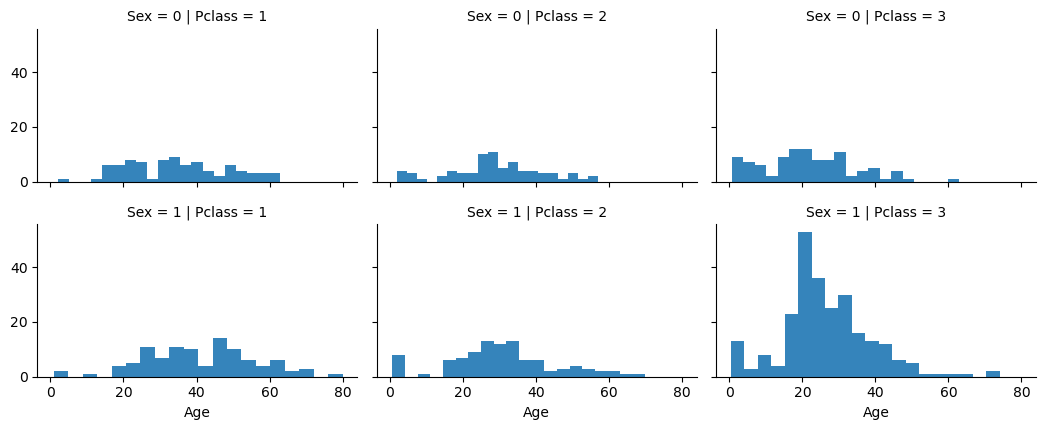

In [25]:
# grid = sns.FacetGrid( train_df, col = 'Pclass', hue = 'Sex' ) 
grid = sns.FacetGrid( train_df, row = 'Sex', col = 'Pclass' , height = 2.2 , aspect = 1.6 ) 
grid.map ( plt.hist , 'Age', alpha = 0.9, bins = 20 ) 

Let us start by preparing an empty array to contain guessed Age values based on Pclass x Gender combinations.

In [26]:
guess_age = np.zeros((2, 3)) 
guess_age

array([[0., 0., 0.],
       [0., 0., 0.]])

Now we iterate over Sex (0 or 1) and Pclass (1, 2, 3) to calculate guessed values of Age for the six combinations.

In [27]:
for dataset in combine : 
    for i in range ( 2 ) : 
        for j in range ( 3 ) : 
            data_ary = dataset[( dataset['Sex'] == i ) & (dataset['Pclass'] == j + 1)]['Age'].dropna()

            # generating the value for guess age with mean and std with every set .....
            mean_value = data_ary. mean()
            std_value = data_ary.std()
            guess_value = rnd. uniform ( mean_value - std_value, mean_value + std_value ) 

            # generating the value for guess age with median value for every set ......
            median_value = data_ary. median()

            # Convert random age float to nearest .5 age
            guess_age[i, j] = int( median_value/0.5 + 0.5 ) * 0.5 


    # now fill the nan value in Age feature with the generated values : 
    for i in range (2):
        for j in range (3) : 
            dataset.loc[ (dataset['Sex'] == i ) & (dataset['Pclass'] == j +1 ) & (dataset['Age'].isnull()),'Age'] = guess_age [i, j]

train_df.head()           

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,1,22.0,1,0,7.2500,S,1.0
1,1,1,0,38.0,1,0,71.2833,C,2.0
2,1,3,0,26.0,0,0,7.9250,S,3.0
3,1,1,0,35.0,1,0,53.1000,S,2.0
4,0,3,1,35.0,0,0,8.0500,S,1.0


Let us create Age bands and determine correlations with Survived.

In [28]:
train_df['Age_group'] = pd.cut( train_df['Age'], 5 , precision = 1) 
train_df[['Age_group', 'Survived']].groupby( ['Age_group'], as_index = False ) .mean().sort_values( by = 'Age_group', ascending = True )  

C:\Users\amans\AppData\Local\Temp\ipykernel_7516\1286240610.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df[['Age_group', 'Survived']].groupby( ['Age_group'], as_index = False ) .mean().sort_values( by = 'Age_group', ascending = True )


,Age_group,Survived
0,"(0.3, 16.3]",0.550000
1,"(16.3, 32.3]",0.336714
2,"(32.3, 48.2]",0.412844
3,"(48.2, 64.1]",0.434783
4,"(64.1, 80.0]",0.090909


Let us replace Age with ordinals based on these bands.

In [29]:
for dataset in combine : 
    dataset.loc[dataset['Age'] <= 16, 'Age'] = 0 
    dataset.loc[(dataset['Age'] > 16 ) & (dataset['Age'] <= 32 ) , 'Age'] = 1 
    dataset.loc[(dataset['Age'] > 32) & (dataset['Age'] <= 48 ) , 'Age'] = 2 
    dataset.loc[(dataset['Age'] > 48 ) & (dataset['Age'] <= 64 ) , 'Age'] = 3
    dataset.loc[dataset['Age'] > 64 , 'Age'] = 4  

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Age_group
0,0,3,1,1.0,1,0,7.2500,S,1.0,"(16.3, 32.3]"
1,1,1,0,2.0,1,0,71.2833,C,2.0,"(32.3, 48.2]"
2,1,3,0,1.0,0,0,7.9250,S,3.0,"(16.3, 32.3]"
3,1,1,0,2.0,1,0,53.1000,S,2.0,"(32.3, 48.2]"
4,0,3,1,2.0,0,0,8.0500,S,1.0,"(32.3, 48.2]"


Now we can remove the AgeBand feature.

In [30]:
train_df.drop( ['Age_group'] , axis = 1 , inplace = True ) 
combine = [ train_df, test_df ]
train_df.head(), test_df.head()


(   Survived  Pclass  Sex  Age  SibSp  Parch     Fare Embarked  Title
 0         0       3    1  1.0      1      0   7.2500        S    1.0
 1         1       1    0  2.0      1      0  71.2833        C    2.0
 2         1       3    0  1.0      0      0   7.9250        S    3.0
 3         1       1    0  2.0      1      0  53.1000        S    2.0
 4         0       3    1  2.0      0      0   8.0500        S    1.0,
    PassengerId  Pclass  Sex  Age  SibSp  Parch     Fare Embarked  Title
 0          892       3    1  2.0      0      0   7.8292        Q    1.0
 1          893       3    0  2.0      1      0   7.0000        S    2.0
 2          894       2    1  3.0      0      0   9.6875        Q    1.0
 3          895       3    1  1.0      0      0   8.6625        S    1.0
 4          896       3    0  1.0      1      1  12.2875        S    2.0)

### Create new feature combining existing features
    We can create a new feature for FamilySize which combines Parch and SibSp. This will enable us to drop Parch and SibSp from our datasets.

In [31]:
for dataset in combine : 
    dataset['Family'] = dataset['Parch'] + dataset['SibSp']

train_df[['Family', 'Survived']]. groupby( ['Family'], as_index = False ) .mean(). sort_values( by = 'Survived', ascending = False ) 

,Family,Survived
3,3,0.724138
2,2,0.578431
1,1,0.552795
6,6,0.333333
0,0,0.303538
4,4,0.200000
5,5,0.136364
7,7,0.000000
8,10,0.000000


We can create another feature called IsAlone.

In [32]:
for dataset in combine : 
    dataset['IsAlone'] = 0 
    dataset.loc[ dataset['Family'] == 0 , 'IsAlone'] = 1 

train_df[['IsAlone', 'Survived']].groupby(['IsAlone'], as_index = False ). mean()

,IsAlone,Survived
0,0,0.505650
1,1,0.303538


In [33]:
train_df.drop(['Parch', 'SibSp', 'Family'] , axis = 1 , inplace = True ) 
test_df.drop(['Parch', 'SibSp', 'Family'], axis = 1 , inplace= True ) 

combine = [train_df, test_df ]
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone
0,0,3,1,1.0,7.2500,S,1.0,0
1,1,1,0,2.0,71.2833,C,2.0,0
2,1,3,0,1.0,7.9250,S,3.0,1
3,1,1,0,2.0,53.1000,S,2.0,0
4,0,3,1,2.0,8.0500,S,1.0,1


In [34]:
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone
0,0,3,1,1.0,7.2500,S,1.0,0
1,1,1,0,2.0,71.2833,C,2.0,0
2,1,3,0,1.0,7.9250,S,3.0,1
3,1,1,0,2.0,53.1000,S,2.0,0
4,0,3,1,2.0,8.0500,S,1.0,1


We can also create an artificial feature combining Pclass and Age.

In [35]:
for dataset in combine : 
    dataset['Age*Class'] = dataset.Age * dataset.Pclass

train_df.loc[: , ['Age*Class', 'Age', 'Pclass']].head()

,Age*Class,Age,Pclass
0,3.0,1.0,3
1,2.0,2.0,1
2,3.0,1.0,3
3,2.0,2.0,1
4,6.0,2.0,3


### Completing a categorical feature
    Embarked feature takes S, Q, C values based on port of embarkation. Our training dataset has two missing values. We simply fill these with the most common occurance.

In [36]:
freq_port = train_df.Embarked.dropna().mode()[0]
freq_port

'S'

In [37]:
for dataset in combine : 
    dataset['Embarked'] = dataset['Embarked'].fillna(freq_port ) 

train_df[['Embarked', 'Survived']]. groupby(['Embarked'], as_index = False ). mean().sort_values( by = 'Survived', ascending = False ) 

,Embarked,Survived
0,C,0.553571
1,Q,0.389610
2,S,0.339009


### Converting categorical feature to numeric¶
    We can now convert the EmbarkedFill feature by creating a new numeric Port feature.

In [38]:
for dataset in combine : 
    dataset['Embarked'] = dataset['Embarked'].map( {'S': 0 , 'C': 1, 'Q': 2 }) .astype(int) 

train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,0,3,1,1.0,7.2500,0,1.0,0,3.0
1,1,1,0,2.0,71.2833,1,2.0,0,2.0
2,1,3,0,1.0,7.9250,0,3.0,1,3.0
3,1,1,0,2.0,53.1000,0,2.0,0,2.0
4,0,3,1,2.0,8.0500,0,1.0,1,6.0


In [39]:
test_df.isnull().sum()

PassengerId    0
Pclass         0
Sex            0
Age            0
Fare           1
Embarked       0
Title          0
IsAlone        0
Age*Class      0
dtype: int64

### Quick completing and converting a numeric feature
    We can now complete the Fare feature for single missing value in test dataset using mode to get the value that occurs most frequently for this feature. We do this in a single line of code.
    
    Note that we are not creating an intermediate new feature or doing any further analysis for correlation to guess missing feature as we are replacing only a single value. The completion goal achieves desired requirement for model algorithm to operate on non-null values.
    
    We may also want round off the fare to two decimals as it represents currency.

In [40]:
test_df['Fare'].fillna( test_df['Fare'].dropna().median(), inplace = True ) 
test_df.isnull().sum()

C:\Users\amans\AppData\Local\Temp\ipykernel_7516\232505801.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Fare'].fillna( test_df['Fare'].dropna().median(), inplace = True )


PassengerId    0
Pclass         0
Sex            0
Age            0
Fare           0
Embarked       0
Title          0
IsAlone        0
Age*Class      0
dtype: int64

We can create FareBand ( group of fare ).

In [44]:
train_df['FareBand'] = pd.qcut( train_df ['Fare'], 4 , precision = 1) 
train_df[['FareBand', 'Survived']].groupby(['FareBand'], as_index = False ).mean().sort_values( by = 'Survived', ascending = True ) 

C:\Users\amans\AppData\Local\Temp\ipykernel_7516\840042857.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df[['FareBand', 'Survived']].groupby(['FareBand'], as_index = False ).mean().sort_values( by = 'Survived', ascending = True )


,FareBand,Survived
0,"(-0.1, 7.9]",0.197309
1,"(7.9, 14.5]",0.303571
2,"(14.5, 31.0]",0.454955
3,"(31.0, 512.3]",0.581081


Convert the Fare feature to ordinal values based on the FareBand.

In [50]:
for dataset in combine : 
    dataset.loc[ dataset['Fare'] <= 7.9, 'Fare'] = 0 
    dataset.loc[ (dataset['Fare'] > 7.9 ) & ( dataset['Fare'] <= 14.5 ), 'Fare'] = 1
    dataset.loc[( dataset['Fare'] > 14.5 ) & (dataset['Fare'] <= 31.0 ), 'Fare'] = 2 
    dataset.loc[ dataset['Fare'] > 31.0 , 'Fare'] = 3 

train_df.drop(['FareBand'], axis = 1 , inplace = True ) 
combine = [train_df, test_df ]
train_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,0,3,1,1.0,0,0,1.0,0,3.0
1,1,1,0,2.0,0,1,2.0,0,2.0
2,1,3,0,1.0,0,0,3.0,1,3.0
3,1,1,0,2.0,0,0,2.0,0,2.0
4,0,3,1,2.0,0,0,1.0,1,6.0


And the test dataset.

In [51]:
test_df.head()

,PassengerId,Pclass,Sex,Age,Fare,Embarked,Title,IsAlone,Age*Class
0,892,3,1,2.0,0,2,1.0,1,6.0
1,893,3,0,2.0,0,0,2.0,0,6.0
2,894,2,1,3.0,0,2,1.0,1,6.0
3,895,3,1,1.0,0,0,1.0,1,3.0
4,896,3,0,1.0,0,0,2.0,0,3.0


## Model, predict and solve
    Now we are ready to train a model and predict the required solution. There are 60+ predictive modelling algorithms to choose from. We must understand the type of problem and solution requirement to narrow down to a select few models which we can evaluate. Our problem is a classification and regression problem. We want to identify relationship between output (Survived or not) with other variables or features (Gender, Age, Port...). We are also perfoming a category of machine learning which is called supervised learning as we are training our model with a given dataset. With these two criteria - Supervised Learning plus Classification and Regression, we can narrow down our choice of models to a few. These include:

    - Logistic Regression
    - KNN or k-Nearest Neighbors
    - Support Vector Machines
    - Naive Bayes classifier
    - Decision Tree
    - Random Forrest
    - Perceptron
    - Artificial neural network
    - RVM or Relevance Vector Machine

In [56]:
x_train = train_df.drop(['Survived'], axis = 1 )
y_train = train_df['Survived']
x_test = test_df.drop(['PassengerId'], axis = 1 ) 
x_train.shape, y_train.shape , x_test.shape

((891, 8), (891,), (418, 8))

Logistic Regression is a useful model to run early in the workflow. Logistic regression measures the relationship between the categorical dependent variable (feature) and one or more independent variables (features) by estimating probabilities using a logistic function, which is the cumulative logistic distribution.

Note the confidence score generated by the model based on our training dataset.

In [ ]:
#  Logistic regreassion : 

logreg = LogisticRegrssion()
